### Loading Data and Visualizing Word Count Distribution

In this section, we perform the following:

1. **Data Loading**: We load the dataset containing Amazon product reviews from a CSV file for analysis.
2. **Histogram Plotting**: We define a function to visualize the distribution of word counts in the reviews by plotting a histogram. This will help us understand the variability in review lengths.


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


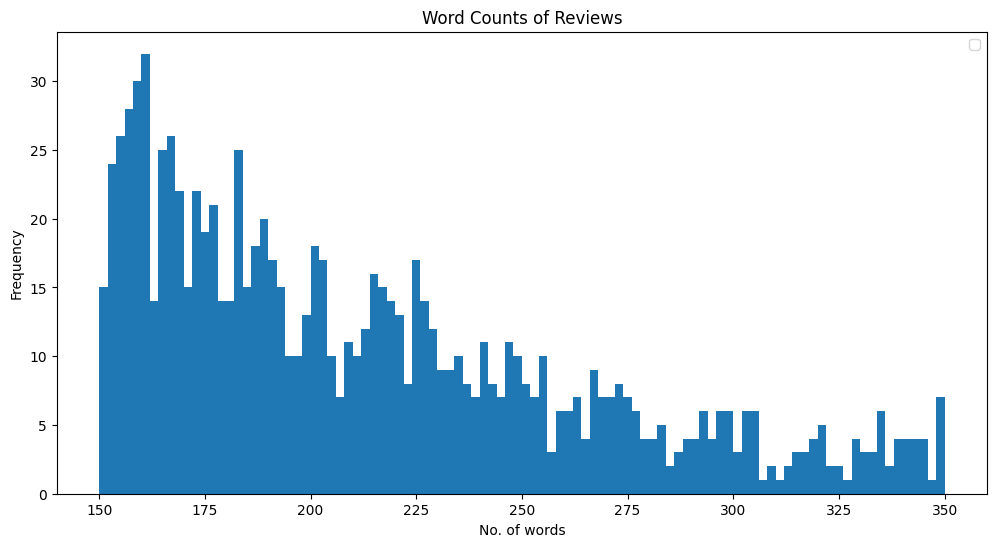

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("./Input/input.csv")

def plot_histogram(word_counts):
    plt.figure(figsize=(12,6))
    plt.hist(word_counts, bins = 100)
    plt.title("Word Counts of Reviews")
    plt.xlabel("No. of words")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()
    
plot_histogram(df["Words"].tolist())

### Summarizing an Example Review Using Pretrained Models

In this section, we perform the following steps:

1. **Dataset Creation**: We create a dataset from a pandas DataFrame containing product reviews using the `datasets` library.
2. **Select a Sample Review**: We extract the first review from the dataset for summarization.
3. **Summarization with PEGASUS**: 
   - We initialize a summarization pipeline using the `google/pegasus-cnn_dailymail` model.
   - The original review is displayed, followed by its summarized output.
4. **Summarization with T5**: 
   - We set up another summarization pipeline using the `t5-large` model.
   - The original review is summarized, and the output is displayed.
5. **Summarization with BART**: 
   - Finally, we use the `facebook/bart-large-cnn` model to summarize the original review.
   - The summarized text is printed.

In [25]:
width = 100
from datasets import Dataset
dataset = Dataset.from_pandas(df)
sample_text = dataset["Review"][0]

In [26]:

print("#################### Original Review ####################".center(width))
print(sample_text)
from transformers import pipeline, set_seed
set_seed(42)

pipe =  pipeline(
    "summarization",
    model="google/pegasus-cnn_dailymail",
    device = 0
)
pipe_out = pipe(sample_text)
print("#################### Summary: PEGASUS ####################".center(width))
print(pipe_out[0]["summary_text"].replace(" .<n>", "."))

pipe =  pipeline(
    "summarization",
    model="t5-large",
    device = 0
)
pipe_out = pipe(sample_text)
print("#################### Summary: T5 ####################".center(width))
print(pipe_out[0]["summary_text"])
pipe =  pipeline(
    "summarization",
    model="facebook/bart-large-cnn",
    device = 0
)
pipe_out = pipe(sample_text)
print("#################### Summary: BART ####################".center(width))
print(pipe_out[0]["summary_text"])

                     #################### Original Review ####################                      
So I've been a pretty big fan of Amazon stuff for sometime. I use Amazon Basics stuff whenever I can. I also rarely leave reviews.But this thing was a big enough disappointment and continues to be a frustration that I figured people need to know some stuff.First off, as an Alexa device, it's fine. Plays music, does the 4 other things Alexa is able to do (different rant).But one of the main reasons I got this thing wasn't for Alexa or as just a music player, I wanted to make a 2-studio-1-subwoofer home theater.Well it really sucks at that so far. Connecting using the Alexa app is fairly simple, but it just refuses to be a reliable home theater system. It constantly drops sound, or has intermittent sound loss. Happens randomly. Sometimes I'll just turn on the TV and only the sub will be working. So I'll have to recreate the entire home theater system. It's also really picky about what it 

2024-10-20 20:35:32.737560: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-10-20 20:35:33.012951: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-20 20:35:34.533815: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
Some weights of PegasusForConditionalGeneration were not initialized from the model checkpoint at google/pegasus-cnn_dailymail and are newly initialized: ['model.decoder.embed_positions.weight', 'model.encoder.embed_positions.weight']
You should prob

                     #################### Summary: PEGASUS ####################                     
Connecting using the Alexa app is fairly simple, but it just refuses to be a reliable home theater system.It constantly drops sound, or has intermittent sound loss. Happens randomly. Sometimes I'll just turn on the TV and only the sub will be working.If you're looking for a better sound quality home theater than a priced sound barsub combo will probably beat whatever studiosub combo (dollar to dollar)


OutOfMemoryError: CUDA out of memory. Tried to allocate 16.00 MiB. GPU 0 has a total capacity of 7.79 GiB of which 6.88 MiB is free. Including non-PyTorch memory, this process has 7.73 GiB memory in use. Of the allocated memory 7.55 GiB is allocated by PyTorch, and 15.65 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [28]:
from transformers import pipeline, set_seed

# Set seed for reproducibility
set_seed(42)

def summarize_text(sample_text, model_name, special_handling=False, width=80):
    # Initialize the pipeline with the given model
    pipe = pipeline("summarization", model=model_name, device=0)
    # Generate summary
    pipe_out = pipe(sample_text)
    summary = pipe_out[0]["summary_text"]
    
    # Special handling for PEGASUS model
    if special_handling:
        summary = summary.replace(" .<n>", ".")
    
    # Print the summary
    print(f"#################### Summary: {model_name.split('/')[-1].upper()} ####################".center(width))
    print(summary)

# Sample text (replace with your actual sample text)
sample_text = "Your review or text here"

# Print the original review
width = 80  # Adjust the width for centering
print("#################### Original Review ####################".center(width))
print(sample_text)

# Summarize using PEGASUS with special handling
summarize_text(sample_text, "google/pegasus-cnn_dailymail", special_handling=True)

# Summarize using T5
summarize_text(sample_text, "t5-large")

# Summarize using BART
summarize_text(sample_text, "facebook/bart-large-cnn")


           #################### Original Review ####################            
Your review or text here


Some weights of PegasusForConditionalGeneration were not initialized from the model checkpoint at google/pegasus-cnn_dailymail and are newly initialized: ['model.decoder.embed_positions.weight', 'model.encoder.embed_positions.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


OutOfMemoryError: CUDA out of memory. Tried to allocate 376.00 MiB. GPU 0 has a total capacity of 7.79 GiB of which 6.88 MiB is free. Including non-PyTorch memory, this process has 7.73 GiB memory in use. Of the allocated memory 7.55 GiB is allocated by PyTorch, and 15.65 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [3]:
from tqdm import tqdm
import torch
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [9]:
def chunks(list_of_elements, batch_size):
    """Yield successive batch-sized chunks from list_of_elements."""
    for i in range(0, len(list_of_elements), batch_size):
        yield list_of_elements[i : i + batch_size]

In [27]:
def generate_summaries(dataset, model, tokenizer, batch_size=16, device=device, column_text="Review", model_type="generic"):
    review_batches = list(chunks(dataset[column_text], batch_size))
    s = []
    for review_batch in tqdm(review_batches, total=len(review_batches)):
        inputs = tokenizer(review_batch, max_length=1024, truncation=True,
                           padding="max_length", return_tensors="pt")
        summaries = model.generate(input_ids=inputs["input_ids"].to(device),
                                   attention_mask=inputs["attention_mask"].to(device), 
                                   length_penalty=0.8, num_beams=8, max_length=128)
        decoded_summaries = [tokenizer.decode(s, skip_special_tokens=True, 
                                              clean_up_tokenization_spaces=True) 
                             for s in summaries]
        
        # Special token replacement for PEGASUS
        if model_type.lower() == "pegasus":
            decoded_summaries = [d.replace("<n>", " ") for d in decoded_summaries]
        
        s.append(decoded_summaries)
    return s

In [8]:
model_ckpt = "google/pegasus-cnn_dailymail"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
model = AutoModelForSeq2SeqLM.from_pretrained(model_ckpt).to(device)

/home/taufiq/anaconda3/lib/python3.9/site-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of PegasusForConditionalGeneration were not initialized from the model checkpoint at google/pegasus-cnn_dailymail and are newly initialized: ['model.decoder.embed_positions.weight', 'model.encoder.embed_positions.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [19]:
s_pegasus = summaries_pegasus(dataset, model, tokenizer, batch_size=1, model_type="pegasus")

100%|███████████████████████████████████████████| 1000/1000 [22:53<00:00,  1.37s/it]


In [11]:
def get_flat_list(nested_list):
    flat_list = [item for sublist in nested_list for item in sublist]
    return flat_list

In [21]:
flat_pegasus = get_flat_list(s_pegasus)

In [22]:
df["S_pegasus"] = flat_pegasus

In [23]:
model_ckpt = "facebook/bart-large-cnn"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
model = AutoModelForSeq2SeqLM.from_pretrained(model_ckpt).to(device)

/home/taufiq/anaconda3/lib/python3.9/site-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [26]:
s_bart = summaries_bart(dataset, model, tokenizer, batch_size=1)

100%|███████████████████████████████████████████| 1000/1000 [22:34<00:00,  1.35s/it]


In [27]:
flat_bart = get_flat_list(s_bart)

In [28]:
df["S_bart"] = flat_bart

In [6]:
model_ckpt = "t5-large"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
model = AutoModelForSeq2SeqLM.from_pretrained(model_ckpt).to(device)

/home/taufiq/anaconda3/lib/python3.9/site-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [10]:
s_t5 = summaries_t5(dataset, model, tokenizer, batch_size=1)

100%|███████████████████████████████████████████| 1000/1000 [52:29<00:00,  3.15s/it]


In [12]:
flat_t5 = get_flat_list(s_t5)

In [16]:
df["S_t5"] = flat_t5

In [ ]:
df.to_csv("./Output/summaries.csv")

In [17]:
df = pd.read_csv("./Output/summaries.csv")

In [18]:
from bert_score import score

In [19]:
from bert_score import score

# Assuming df is your dataframe with the relevant columns
# df = pd.read_csv("your_dataframe.csv")  # Load your dataframe if needed

# Function to calculate BERTScore for summaries against the original review
def calculate_bertscore(df, reference_col, summary_col):
    references = df[reference_col].tolist()  # The original reviews
    candidates = df[summary_col].tolist()    # The generated summaries
    
    # Calculate BERTScore
    P, R, F1 = score(candidates, references, lang="en", verbose=True)
    
    # Convert torch tensors to lists
    return P.tolist(), R.tolist(), F1.tolist()

# Calculate BERTScore for PEGASUS
pegasus_P, pegasus_R, pegasus_F1 = calculate_bertscore(df, 'Review', 'S_pegasus')

# Calculate BERTScore for BART
bart_P, bart_R, bart_F1 = calculate_bertscore(df, 'Review', 'S_bart')

# Calculate BERTScore for T5
t5_P, t5_R, t5_F1 = calculate_bertscore(df, 'Review', 'S_t5')

# Add the scores back to the dataframe for comparison
df['pegasus_bert_F1'] = pegasus_F1
df['bart_bert_F1'] = bart_F1
df['t5_bert_F1'] = t5_F1

# Now you can compare the F1 scores
print(df[['pegasus_bert_F1', 'bart_bert_F1', 't5_bert_F1']])


/home/taufiq/anaconda3/lib/python3.9/site-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


calculating scores...
computing bert embedding.


  0%|          | 0/32 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/16 [00:00<?, ?it/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/32 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/16 [00:00<?, ?it/s]

done in 32.19 seconds, 31.06 sentences/sec
     pegasus_bert_F1  bart_bert_F1  t5_bert_F1
0           0.875074      0.891012    0.823803
1           0.906373      0.890209    0.846625
2           0.915366      0.897953    0.847385
3           0.913725      0.907226    0.812147
4           0.940987      0.919554    0.846814
..               ...           ...         ...
995         0.906922      0.908651    0.867608
996         0.907989      0.921766    0.892491
997         0.936786      0.909661    0.842074
998         0.923445      0.905437    0.820183
999         0.877959      0.869960    0.801430

[1000 rows x 3 columns]


In [20]:
import seaborn as sns

(0.7, 1.0)

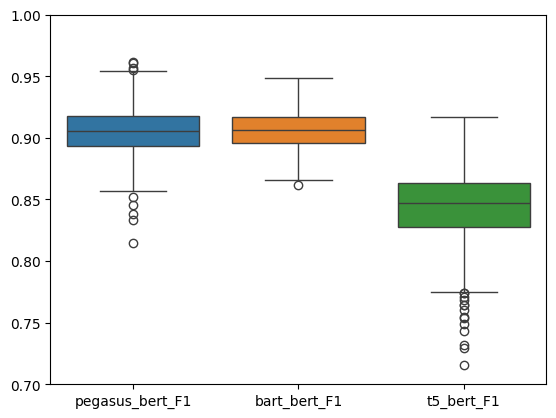

In [24]:
sns.boxplot(data=df[["pegasus_bert_F1", "bart_bert_F1", "t5_bert_F1"]])
plt.ylim(0.7, 1.0)